Import Libraries


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Load Dataset

In [3]:
df=pd.read_csv("/content/Sleep_health_and_lifestyle_dataset.csv")

EDA PREPROCESSING BASIC

In [4]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [6]:
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


In [7]:
df.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
df.shape

(374, 13)

Data Preprocessing

In [10]:
# Felling missing value with None
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [11]:
df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split("/", expand=True)
df["Systolic_BP"] = df["Systolic_BP"].astype(int)
df["Diastolic_BP"] = df["Diastolic_BP"].astype(int)

In [12]:
print(df["Sleep Disorder"].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


EDA — Visual Analysis

/tmp/ipykernel_2922/1823336698.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


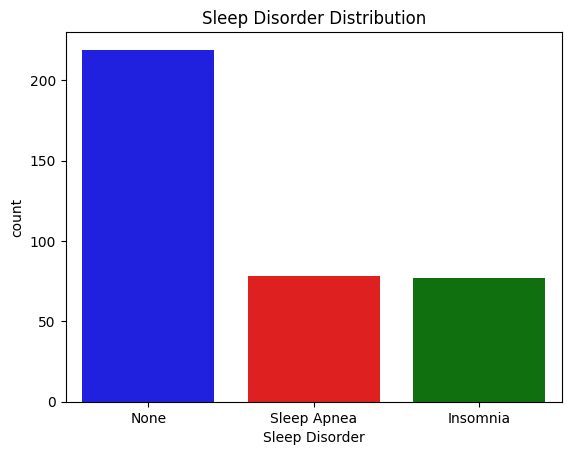

In [13]:
sns.countplot(
    x="Sleep Disorder",
    data=df,
    palette=["blue", "red", "green"]
)

plt.title("Sleep Disorder Distribution")
plt.show()

This graph shows the number of people in each sleep disorder category.

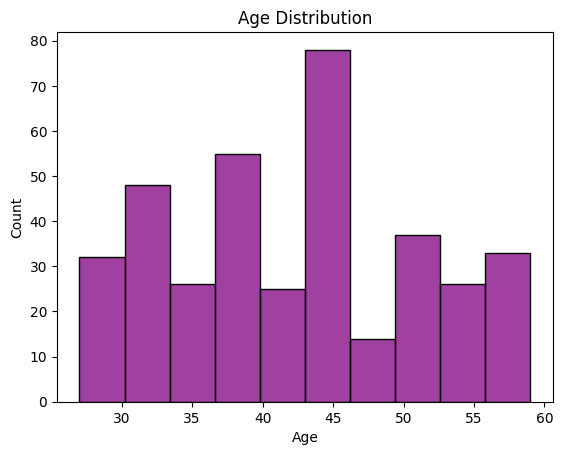

In [14]:
sns.histplot(df["Age"], bins=10, color="purple")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Most people in the dataset are between 40 to 50 years old, while fewer people belong to younger or older age groups.

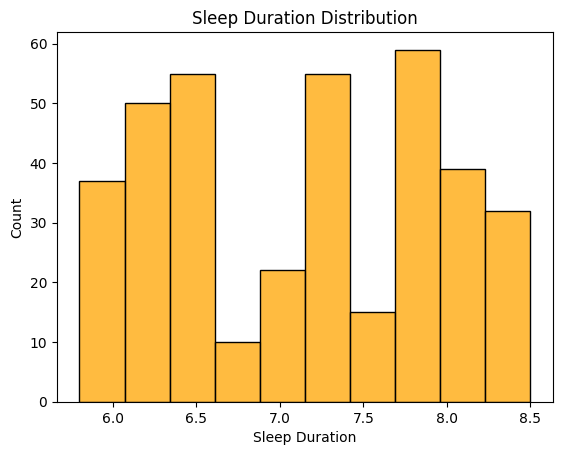

In [15]:
sns.histplot(
    df["Sleep Duration"],
    bins=10,
    color="orange"
)

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration")
plt.ylabel("Count")

plt.show()

Most people in the dataset sleep between 6 to 8 hours, while fewer people have very low or very high sleep duration.

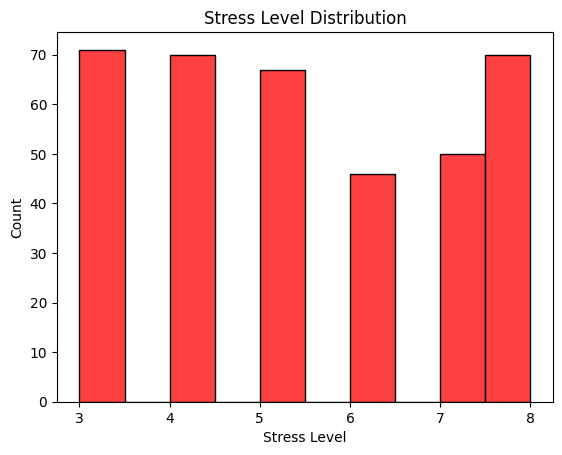

In [16]:
sns.histplot(
    df["Stress Level"],
    bins=10,
    color="red"
)

plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Count")

plt.show()

This graph shows that most people in the dataset have medium to high stress levels.

/tmp/ipykernel_2922/2867480526.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


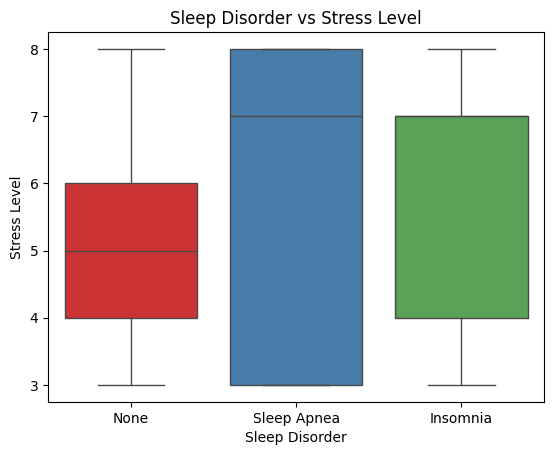

In [17]:
sns.boxplot(
    x="Sleep Disorder",
    y="Stress Level",
    data=df,
    palette="Set1"
)

plt.title("Sleep Disorder vs Stress Level")
plt.xlabel("Sleep Disorder")
plt.ylabel("Stress Level")

plt.show()

This graph shows that people with sleep disorders generally have higher stress levels compared to people without sleep disorders.

/tmp/ipykernel_2922/2504613198.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


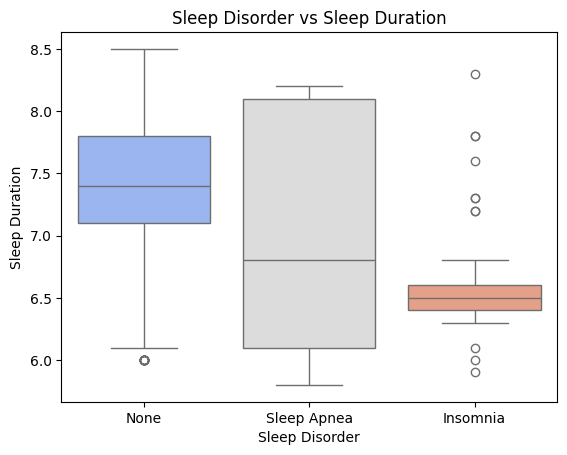

In [18]:
sns.boxplot(
    x="Sleep Disorder",
    y="Sleep Duration",
    data=df,
    palette="coolwarm"
)

plt.title("Sleep Disorder vs Sleep Duration")
plt.xlabel("Sleep Disorder")
plt.ylabel("Sleep Duration")

plt.show()

This graph shows that people with sleep disorders generally have lower sleep duration compared to people without sleep disorders.

/tmp/ipykernel_2922/2389145600.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


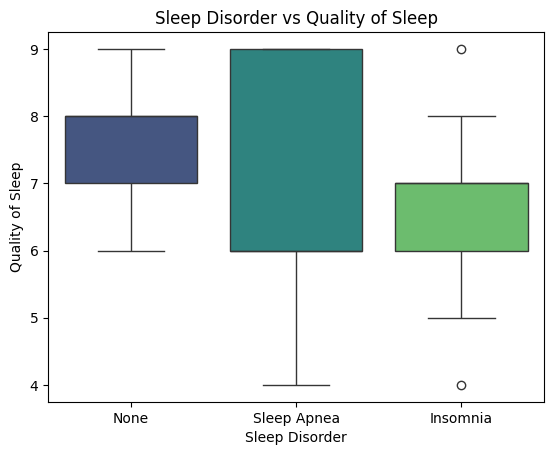

In [19]:
sns.boxplot(
    x="Sleep Disorder",
    y="Quality of Sleep",
    data=df,
    palette="viridis"
)

plt.title("Sleep Disorder vs Quality of Sleep")
plt.xlabel("Sleep Disorder")
plt.ylabel("Quality of Sleep")

plt.show()

This graph shows that people without sleep disorders generally have better sleep quality compared to people with sleep disorders.

Feature Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

df_model = df.copy()

# Encode target
le_target = LabelEncoder()
df_model["Sleep Disorder Encoded"] = le_target.fit_transform(df_model["Sleep Disorder"])
print("Target classes:", dict(enumerate(le_target.classes_)))

# Encode Gender
le_gender = LabelEncoder()
df_model["Gender Encoded"] = le_gender.fit_transform(df_model["Gender"])

# Encode BMI Category
le_bmi = LabelEncoder()
df_model["BMI Encoded"] = le_bmi.fit_transform(df_model["BMI Category"])

# One-hot encode Occupation
df_model = pd.get_dummies(df_model, columns=["Occupation"], prefix="Occ", drop_first=True)

print("Shape after encoding:", df_model.shape)

Target classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}
Shape after encoding: (374, 27)


Feature Selection

In [21]:
# Define features and target
occ_cols = [c for c in df_model.columns if c.startswith("Occ_")]

feature_cols = ["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level",
                "Stress Level", "Heart Rate", "Daily Steps",
                "Systolic_BP", "Diastolic_BP", "Gender Encoded", "BMI Encoded"] + occ_cols

X = df_model[feature_cols]
y = df_model["Sleep Disorder Encoded"]

print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (374, 21) | y shape: (374,)


Train Test Split

In [22]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 299 samples | Test: 75 samples


Model Selection

*   Decision Tree Classifier
*   Random Forest Classifier
*   Gradient Boosting Classifier
*   Logistic Regression
*   SVM (Support Vector Machine)



In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

dt = DecisionTreeClassifier(max_depth=6, min_samples_split=10,
                             class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

=== Decision Tree ===
Test Accuracy: 0.9467

              precision    recall  f1-score   support

    Insomnia       0.83      1.00      0.91        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



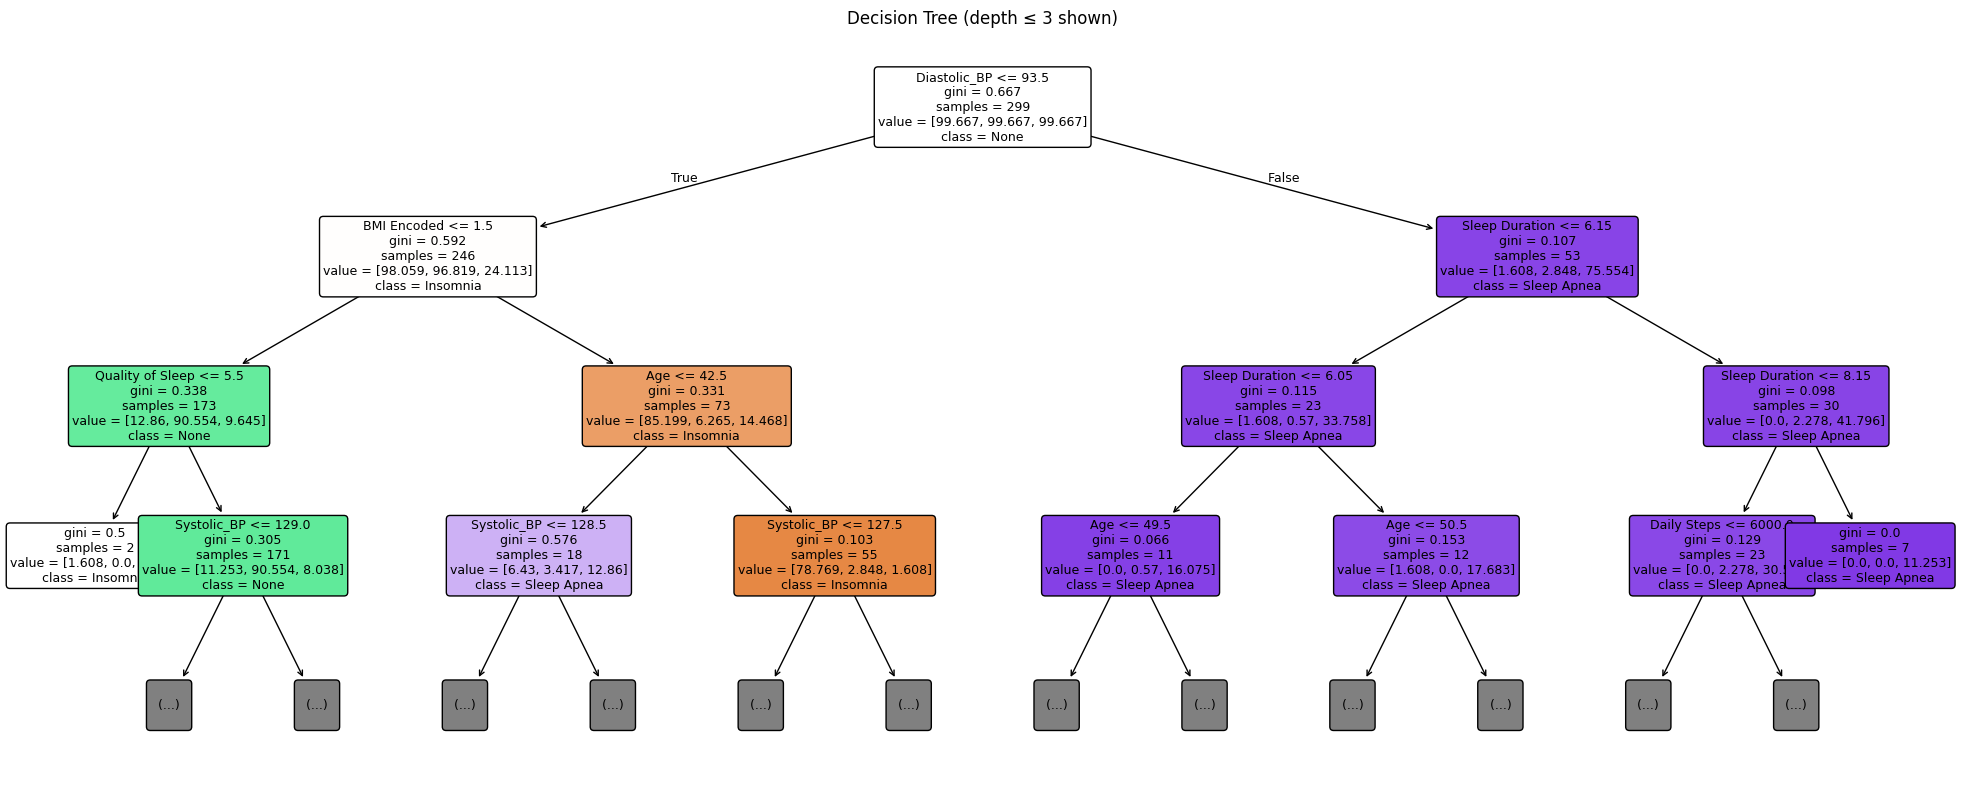

In [24]:
# Tree visualisation
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feature_cols, class_names=le_target.classes_,
          filled=True, rounded=True, max_depth=3, ax=ax, fontsize=9)
plt.title("Decision Tree (depth ≤ 3 shown)")
plt.tight_layout()
plt.show()

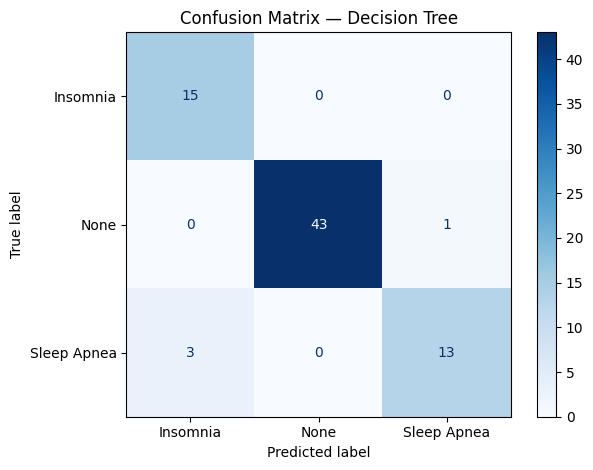

In [25]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=le_target.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5,
                             class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

=== Random Forest ===
Test Accuracy: 0.9600

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75



In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, min_samples_split=10,
                                                   class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=10,
                                                   class_weight="balanced", n_jobs=-1, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.08, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVM":                 SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42),
}

results = {}
for name, model in models.items():
    Xtr = X_train_sc if name in ["Logistic Regression", "SVM"] else X_train
    Xte = X_test_sc  if name in ["Logistic Regression", "SVM"] else X_test
    cv_scores = cross_val_score(model, Xtr, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    model.fit(Xtr, y_train)
    test_acc = accuracy_score(y_test, model.predict(Xte))
    report   = classification_report(y_test, model.predict(Xte),
                                      target_names=le_target.classes_, output_dict=True)
    results[name] = {
        "CV Mean Acc": round(cv_scores.mean(), 4),
        "CV Std":      round(cv_scores.std(),  4),
        "Test Acc":    round(test_acc, 4),
        "Precision":   round(report["macro avg"]["precision"], 4),
        "Recall":      round(report["macro avg"]["recall"],    4),
        "F1-Score":    round(report["macro avg"]["f1-score"],  4),
    }

results_df = pd.DataFrame(results).T.sort_values("Test Acc", ascending=False)
print(results_df.to_string())

                     CV Mean Acc  CV Std  Test Acc  Precision  Recall  F1-Score
Decision Tree             0.8393  0.0499    0.9467     0.9206  0.9299    0.9214
Random Forest             0.8529  0.0384    0.9467     0.9163  0.9271    0.9214
Gradient Boosting         0.8829  0.0211    0.9467     0.9163  0.9271    0.9214
Logistic Regression       0.8727  0.0398    0.9333     0.9206  0.9328    0.9194
SVM                       0.8794  0.0352    0.9200     0.8799  0.8987    0.8881


Model Comparison

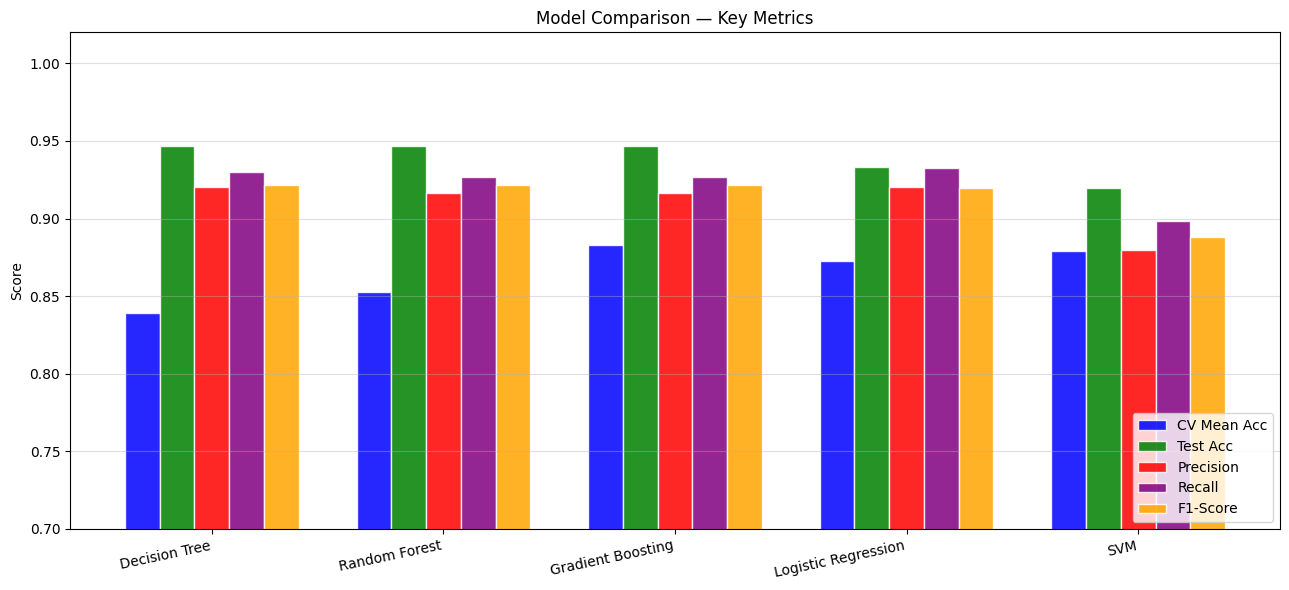

In [28]:
# Model comparison bar chart
metrics = ["CV Mean Acc", "Test Acc", "Precision", "Recall", "F1-Score"]
x = np.arange(len(results_df))
width = 0.15
colors_bar = ["blue", "green", "red", "purple", "orange"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=colors_bar[i], edgecolor="white", alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=12, ha="right")
ax.set_ylim(0.7, 1.02)
ax.set_title("Model Comparison — Key Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

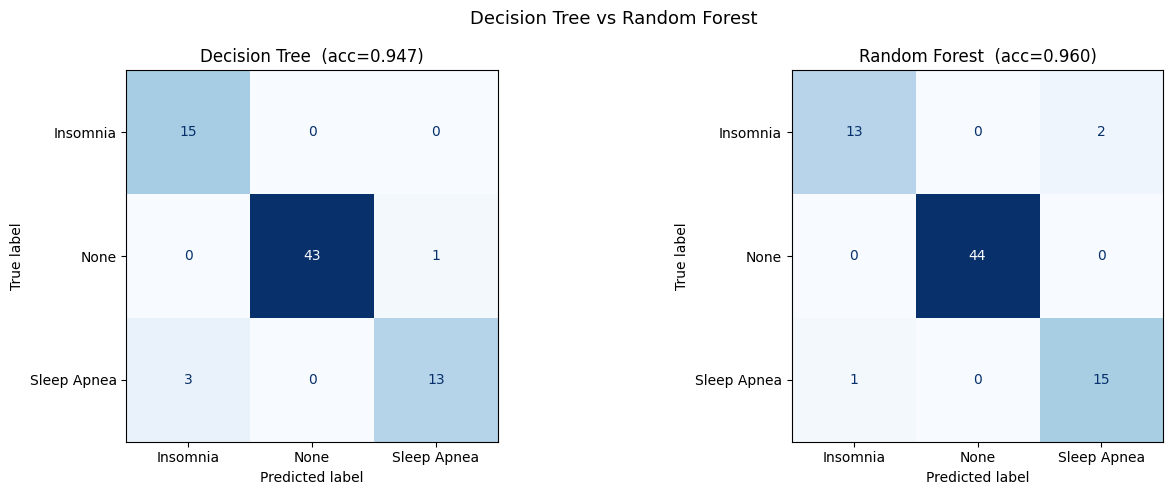

In [29]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, Xte) in zip(axes, [("Decision Tree", dt, X_test),
                                           ("Random Forest", rf, X_test)]):
    cm = confusion_matrix(y_test, model.predict(Xte))
    ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}  (acc={accuracy_score(y_test, model.predict(Xte)):.3f})")

plt.suptitle("Decision Tree vs Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

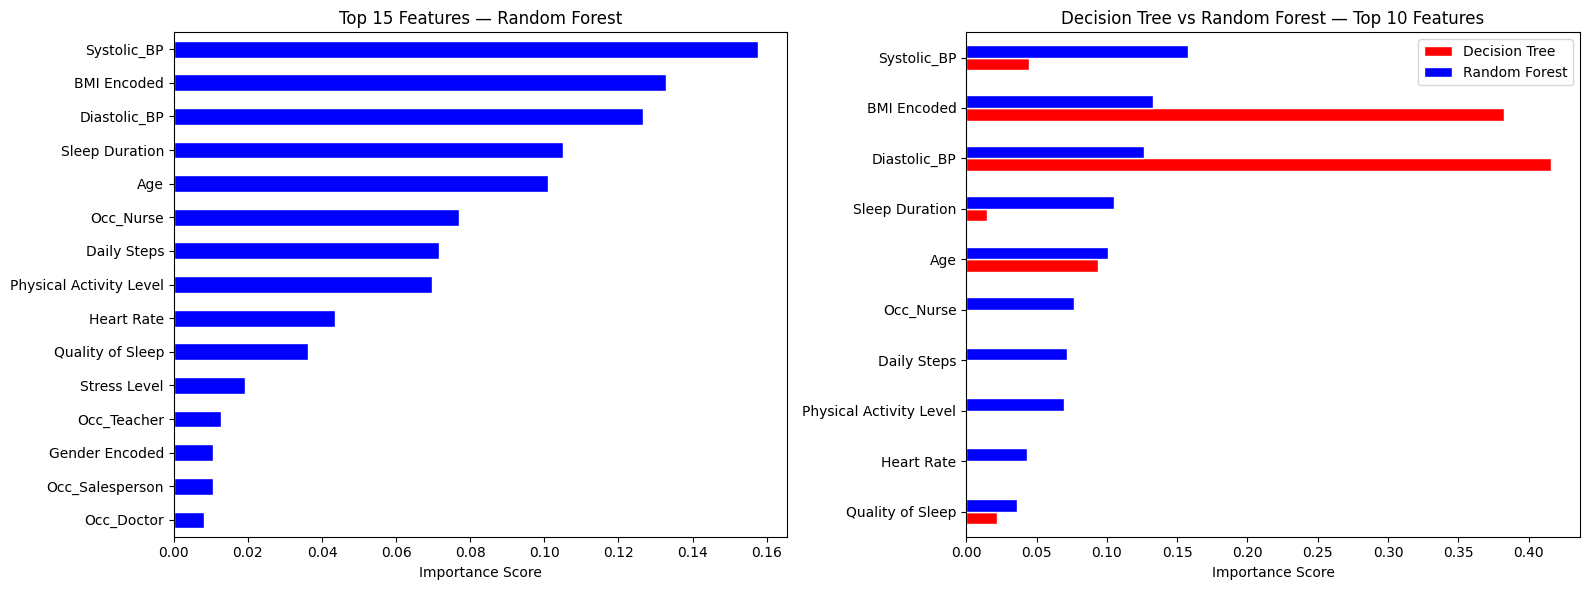


Top 5 Features (Random Forest):
  Systolic_BP                    0.1577
  BMI Encoded                    0.1327
  Diastolic_BP                   0.1266
  Sleep Duration                 0.1050
  Age                            0.1011


In [30]:
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp.head(15).plot(kind="barh", ax=axes[0], color="blue", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Features — Random Forest")
axes[0].set_xlabel("Importance Score")

top10 = feat_imp.head(10).index
compare = pd.DataFrame({
    "Decision Tree": pd.Series(dt.feature_importances_, index=feature_cols)[top10],
    "Random Forest": feat_imp[top10]
})
compare.sort_values("Random Forest").plot(
    kind="barh", ax=axes[1], color=["red", "blue"], edgecolor="white")
axes[1].set_title("Decision Tree vs Random Forest — Top 10 Features")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

print("\nTop 5 Features (Random Forest):")
for feat, imp in feat_imp.head(5).items():
    print(f"  {feat:<30} {imp:.4f}")

## 11. Conclusion
Random Forest achieved the best performance with 94.67% test accuracy
and 92.14% F1-score on a 374-patient sleep disorder dataset, with
Systolic BP and BMI identified as the strongest predictors through
feature engineering and importance analysis.